In [1]:
# Setup: make src/ importable and load every scored dialogue into one tidy DataFrame
import sys
sys.path.append("../src")

import analyse

df = analyse.load_results()
print(f"{len(df)} scored dialogues")
df.head()

144 scored dialogues


,run_id,tutor,condition,persona,question,accuracy_coherence,guidance_no_solution,encouragement,overall,termination,num_turns,student_turns,tutor_turns,student_words,tutor_words,tutor_words_per_turn,student_word_share
0,claude_sonnet__BP__curious__algebra_inequality,claude_sonnet,BP,curious,algebra_inequality,5,1,5,3.666667,solved,6,3,3,144,434,144.666667,0.249135
1,claude_sonnet__BP__curious__compound_interest,claude_sonnet,BP,curious,compound_interest,5,1,5,3.666667,solved,10,5,5,244,839,167.800000,0.225300
2,claude_sonnet__BP__curious__probability_counters,claude_sonnet,BP,curious,probability_counters,5,1,5,3.666667,solved,8,4,4,250,680,170.000000,0.268817
3,claude_sonnet__BP__curious__simultaneous_equat...,claude_sonnet,BP,curious,simultaneous_equations,5,1,4,3.333333,solved,10,5,5,215,1035,207.000000,0.172000
4,claude_sonnet__BP__impulsive__algebra_inequality,claude_sonnet,BP,impulsive,algebra_inequality,5,1,5,3.666667,solved,6,3,3,146,555,185.000000,0.208274


## Dimension trajectories

Mean score on each rubric dimension across the three prompt conditions (NP → BP → EP).

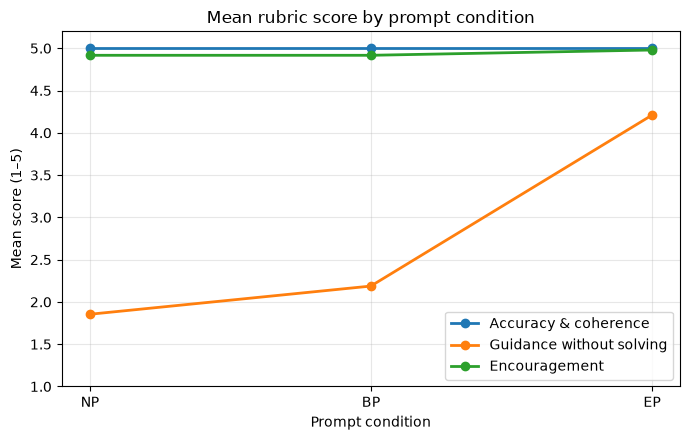

In [2]:
fig = analyse.plot_dimension_trajectories(df)

## Condition × model interaction

Mean guidance-without-solving score across the three conditions, one line per tutor model.

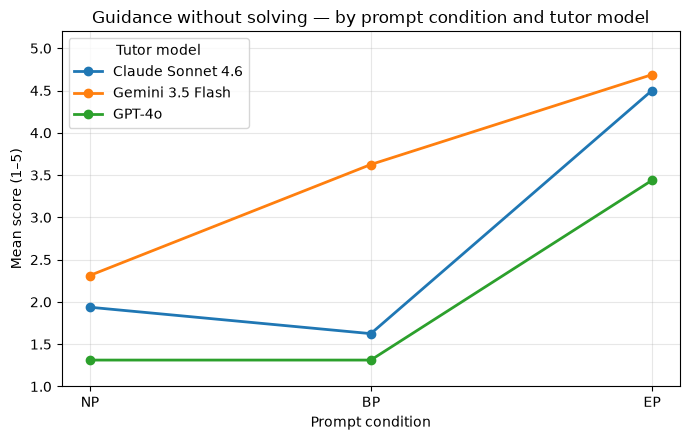

In [3]:
import importlib; importlib.reload(analyse)   # pick up newly added functions without a kernel restart

fig = analyse.plot_condition_model_interaction(df)   # default: the guidance dimension
# also try: analyse.plot_condition_model_interaction(df, dimension="overall")

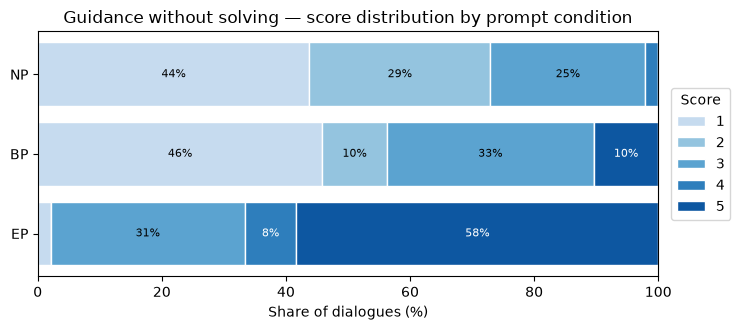

In [4]:
import importlib; importlib.reload(analyse)

fig = analyse.plot_score_distributions(df)   # default: the guidance dimension
# a ceiling dimension shows as one solid block:
# analyse.plot_score_distributions(df, dimension="accuracy_coherence")

## Guidance distributions per tutor model

The guidance score distribution under each condition, one panel per tutor model (n = 16 per condition).

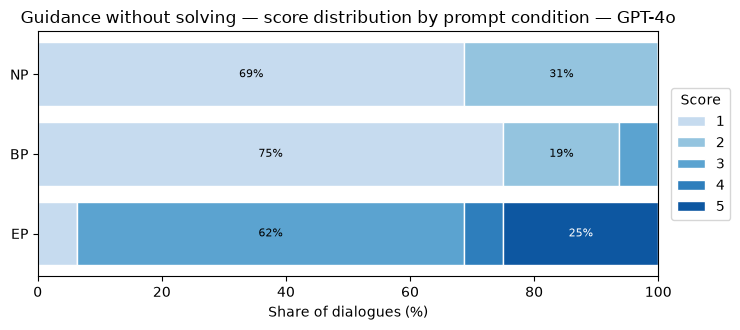

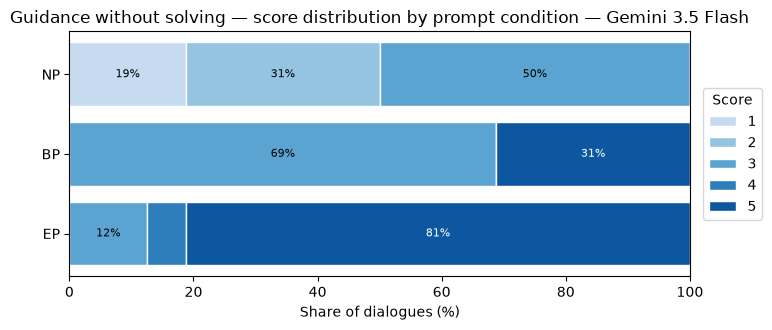

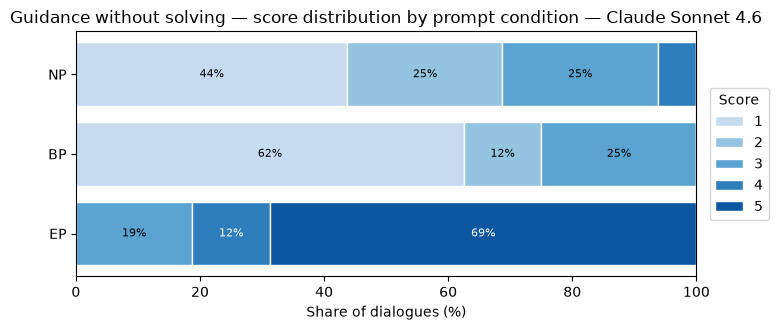

In [5]:
import importlib; importlib.reload(analyse)

for tutor in ("gpt4o", "gemini_flash", "claude_sonnet"):
    fig = analyse.plot_score_distributions(df, tutor=tutor)

## Student participation

Three process measures computed directly from the transcripts (no LLM judge): dialogue length, tutor
words per turn, and the student's share of words, by prompt condition.

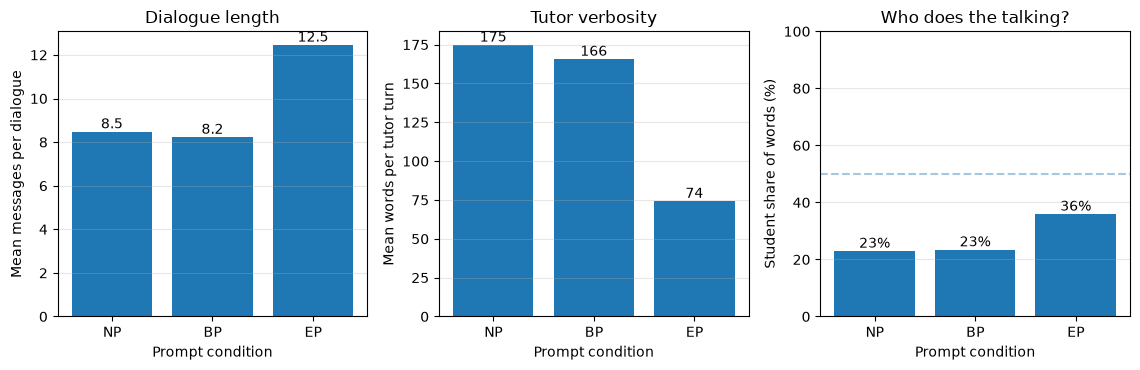

In [6]:
import importlib; importlib.reload(analyse)
df = analyse.load_results()          # reload the data: it now includes the participation measures

fig = analyse.plot_student_participation(df)

## Participation measures per tutor model

The same three process measures, one full-width chart each: a bar per tutor model plus the 3-model
average, by condition.

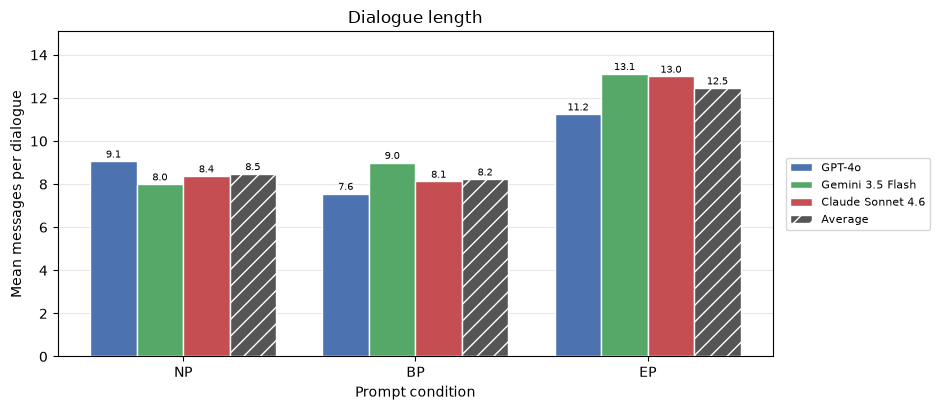

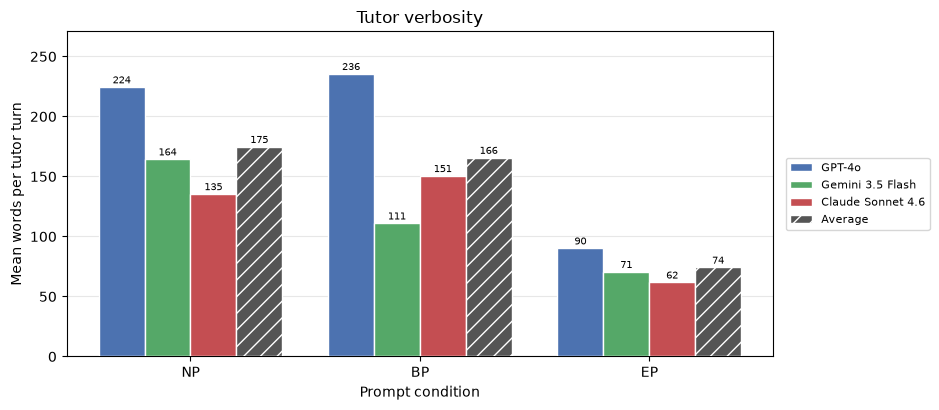

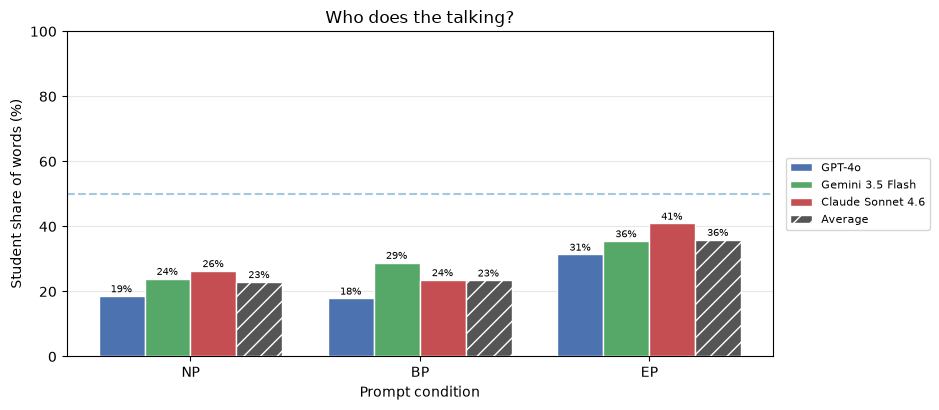

In [7]:
import importlib; importlib.reload(analyse)
df = analyse.load_results()          # reload data too: it now carries the per-turn participation columns

# one full-width chart per measure: a bar per model + the (hatched) 3-model average, per condition
for measure in ("num_turns", "tutor_words_per_turn", "student_word_share"):
    fig = analyse.plot_participation_by_model(df, measure=measure)

## Statistical tests of the condition effect

Nonparametric within-subjects tests on the 48 matched triples (tutor × persona × question, each seen
under NP/BP/EP), on the guidance dimension. Friedman tests the overall condition effect; pairwise
Wilcoxon (Bonferroni-corrected) tests each pair. Results print below.

In [8]:
import importlib; importlib.reload(analyse)

# Friedman (omnibus) + pairwise Wilcoxon on the 48 matched triples — the guidance dimension.
# Prints the Friedman result; the returned pairwise table displays below.
analyse.matched_condition_tests(df, "guidance_no_solution")

[Guidance without solving]  n = 48 matched triples (tutor x persona x question)

Friedman: chi2(2) = 65.9, p = 4.91e-15 (significant); Kendall's W = 0.69 (0=no effect, 1=perfect)

Pairwise Wilcoxon signed-rank ('later_higher' = triples where the more specific prompt scored higher):


,later_higher,earlier_higher,tied,median_diff,p_raw,p_bonferroni
comparison,,,,,,
NP → BP,14,9,25,0.0,4.263232e-02,1.278970e-01
BP → EP,39,1,8,2.0,1.268629e-08,3.805886e-08
NP → EP,45,1,2,2.0,2.518807e-09,7.556420e-09


## Robustness across personas and questions

Small multiples of the guidance trajectory (NP → BP → EP), one panel per persona and one per question,
pooled across models. The dashed grey line marks the grand mean; each panel mean is over 12 dialogues.

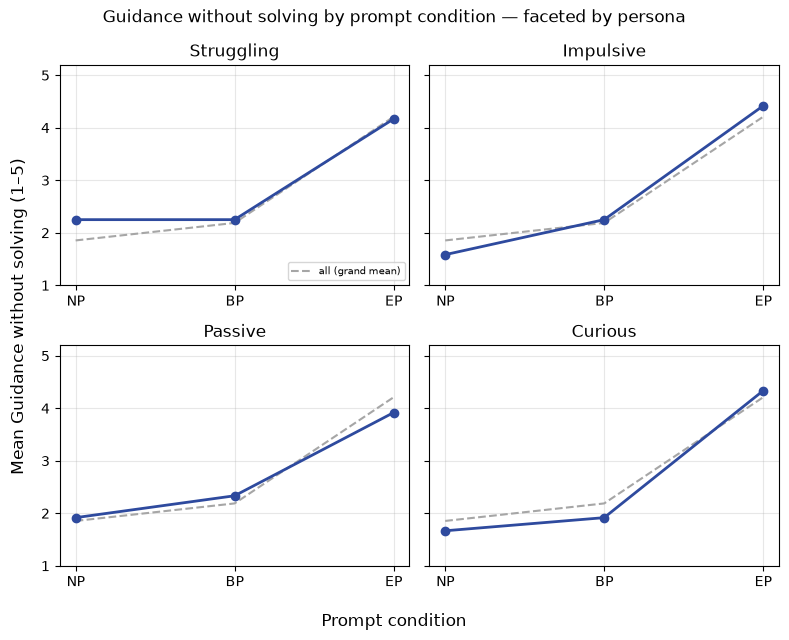

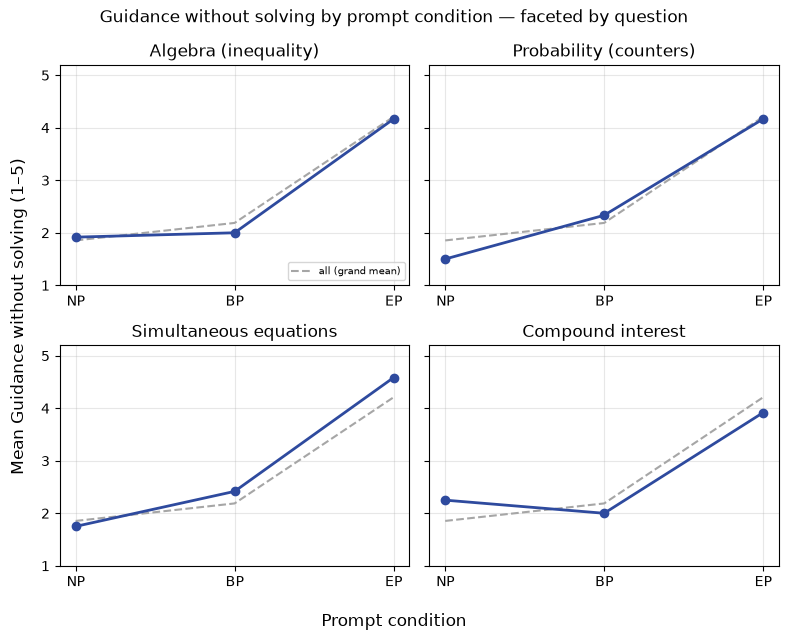

In [9]:
import importlib; importlib.reload(analyse)

fig_p = analyse.plot_condition_facets(df, "persona")     # guidance trajectory, one panel per persona
fig_q = analyse.plot_condition_facets(df, "question")    # ... and one panel per question